# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'
MOMENTS = 15

# Helpeer Functions 

In [3]:
from Tools import CaseNamer, Plotting

In [4]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [5]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [6]:
BOPCOEF_FILE = f'CNAveragedCRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

In [7]:
BopfoxFeatures

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,CN13_NSC_Ainf_0,CN14_NSC_Ainf_0,CN15_NSC_Ainf_0,CN16_NSC_Ainf_0,all_NSC_Binf_0,CN12_NSC_Binf_0,CN13_NSC_Binf_0,CN14_NSC_Binf_0,CN15_NSC_Binf_0,CN16_NSC_Binf_0
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0.0,0.000000,0.0,0.000000,6.222663,0.000000,0.0,0.00000,0.0,0.000000
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.187294,0.000000,0.0,0.00000,0.0,0.000000
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.763108,0.000000,0.0,0.00000,0.0,0.000000
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0.0,0.000000,0.0,0.000000,5.435779,0.000000,0.0,0.00000,0.0,0.000000


In [8]:
composition_features = pd.read_pickle('compo_averages_by_sublattice.pkl')

In [9]:
atomic_features = pd.read_pickle('tables/BestAtomicFeatures.pkl')

In [10]:
atomic_features.columns = atomic_features.columns.str.replace('MagpieData ','')

## clean features: reduntandly convert all features to float and mean across sites

In [11]:
BopfoxFeatures.dropna(how='any',inplace=True)
Mag = Features.MagFeature[BopfoxFeatures.index]
BopfoxFeatures['MagConfig'] = Mag

## concentration feature

In [12]:
X = Features.get_fractions_by_components()

In [13]:
categorical_compo = pd.get_dummies(BS[['atom_A','atom_B','atom_C']])

In [14]:
BOP = pd.concat([BopfoxFeatures, X, categorical_compo, atomic_features, composition_features], axis=1)

In [15]:
BOP

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,CN13_C,CN14_A,CN14_B,CN14_C,CN15_A,CN15_B,CN15_C,CN16_A,CN16_B,CN16_C
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.2,0.0


## define the column names by type of feature

In [16]:
allcolumns = BOP.columns

In [17]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]
columns_cn12 = BOP.columns[BOP.columns.str.contains('CN12')] 
columns_cn14 = BOP.columns[BOP.columns.str.contains('CN14')] 
columns_cn15 = BOP.columns[BOP.columns.str.contains('CN15')] 
columns_cn16 = BOP.columns[BOP.columns.str.contains('CN16')] 
columns_all = BOP.columns[BOP.columns.str.contains('all')] 

In [18]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [19]:
feature_titles

all_NSC_U_bind_0                          $all_U_{bind}$
all_NSC_U_bond_atom_0                $all_U_bond_atom_0$
all_NSC_U_bond_atom_list_0      $all_U_bond_atom_list_0$
CN12_NSC_U_bond_atom_list_0    $CN12_U_bond_atom_list_0$
CN13_NSC_U_bond_atom_list_0    $CN13_U_bond_atom_list_0$
                                         ...            
CN15_B                                          $CN15_B$
CN15_C                                          $CN15_C$
CN16_A                                          $CN16_A$
CN16_B                                          $CN16_B$
CN16_C                                          $CN16_C$
Length: 428, dtype: object

In [20]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [21]:
'CN16_C' in real_feature

True

In [22]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [23]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [24]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [25]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [26]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [27]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [28]:
DATA.shape

(1684, 432)

## B0

In [29]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [30]:
DATA = DATA[DATA['V0']<50]

In [31]:
DATA.shape

(1681, 432)

## Drop Nans !

In [32]:
DATA.dropna(how='any', axis=0,inplace=True)

In [33]:
DATA.shape

(1681, 432)

# Classification and weighting

Text(0, 0.5, '')

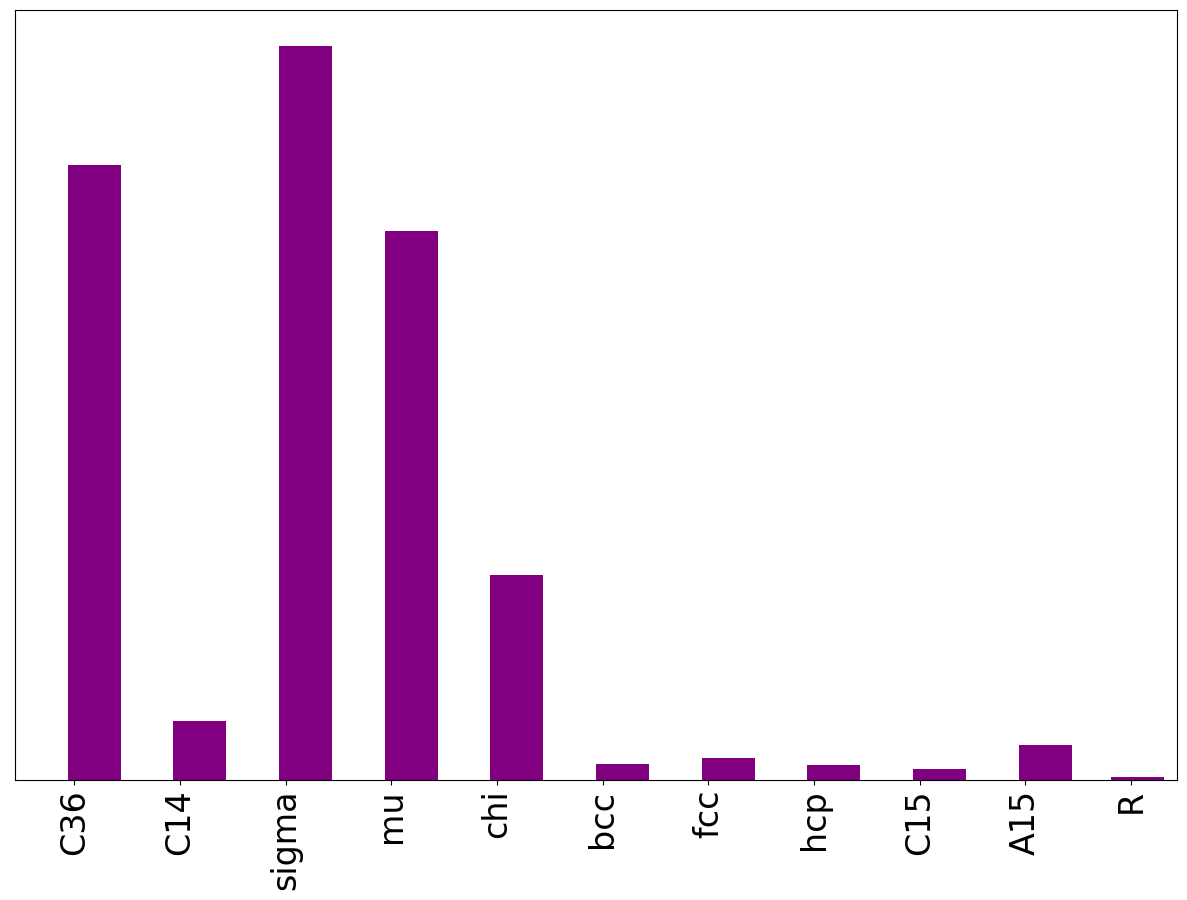

In [34]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [35]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [36]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

## Remove C14!

DATA = DATA[data_w_classes['Class']!='C14']
Classes = Classes[Classes['Class']!='C14']

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [37]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [38]:
from sklearn.feature_selection import  (
    RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [39]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [40]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  Target^{predicted} -  Target^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

# Train test split 

In [41]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [42]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [43]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [44]:
simple_model.fit(X_train,Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', RandomForestRegressor())])

In [45]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [46]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114}}

In [47]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [48]:
simple_model_noscaler.fit(X_train, Y_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [49]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [50]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381}}

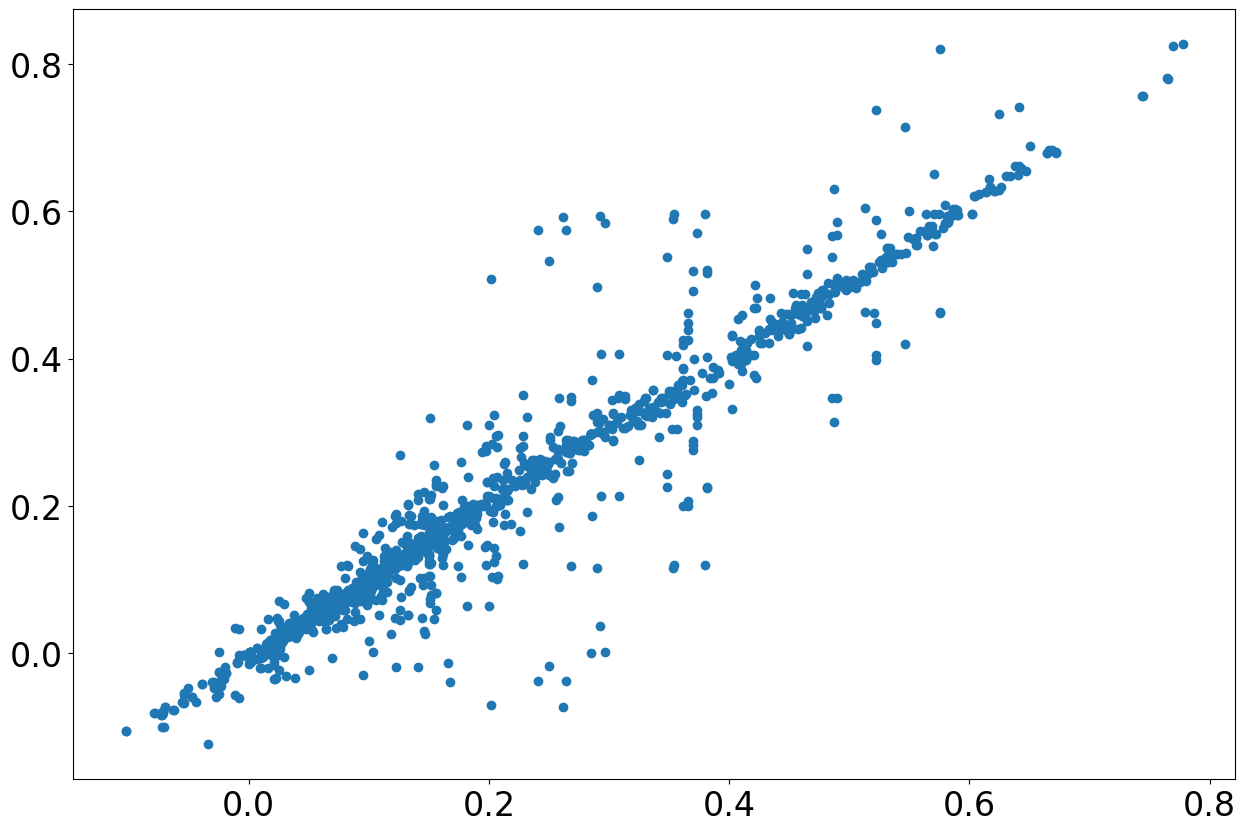

In [51]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

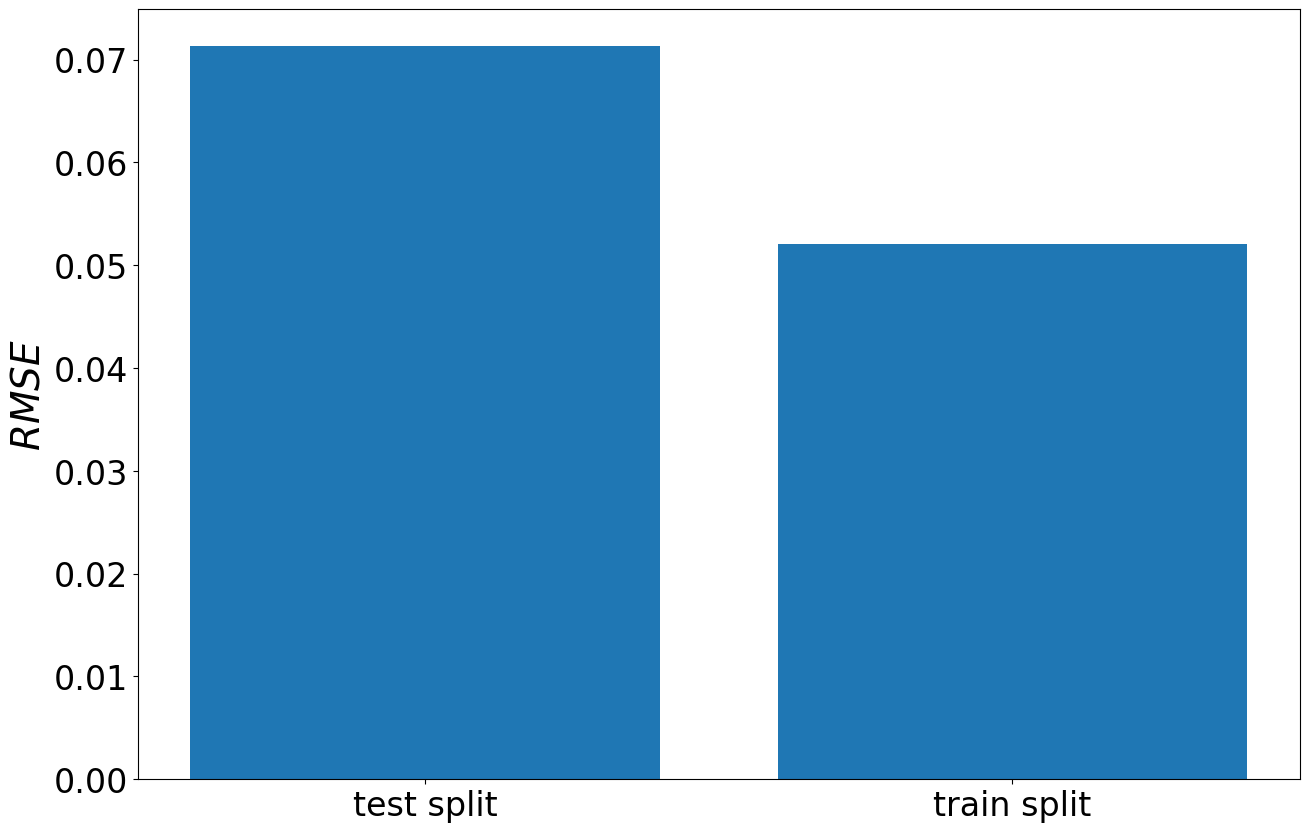

In [52]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [53]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

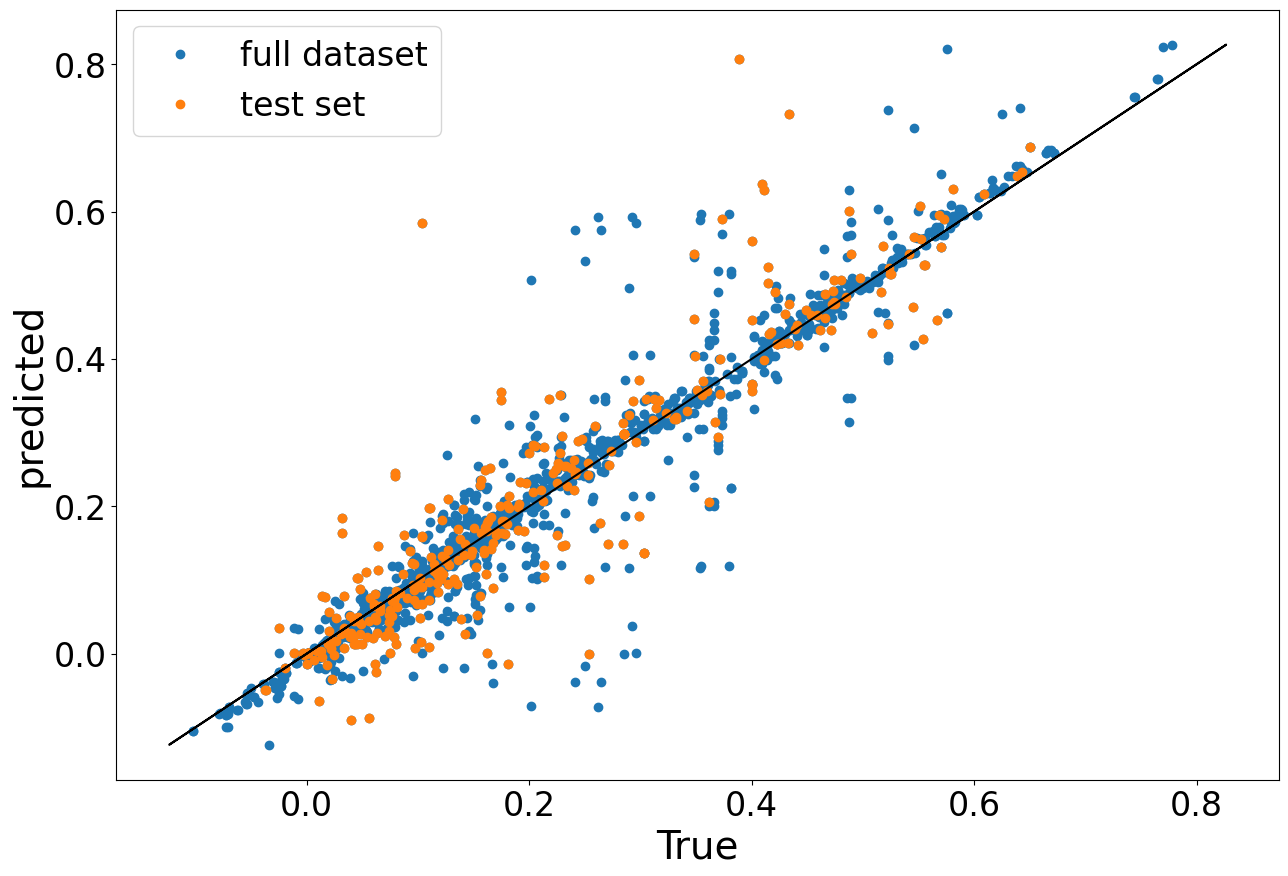

In [54]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

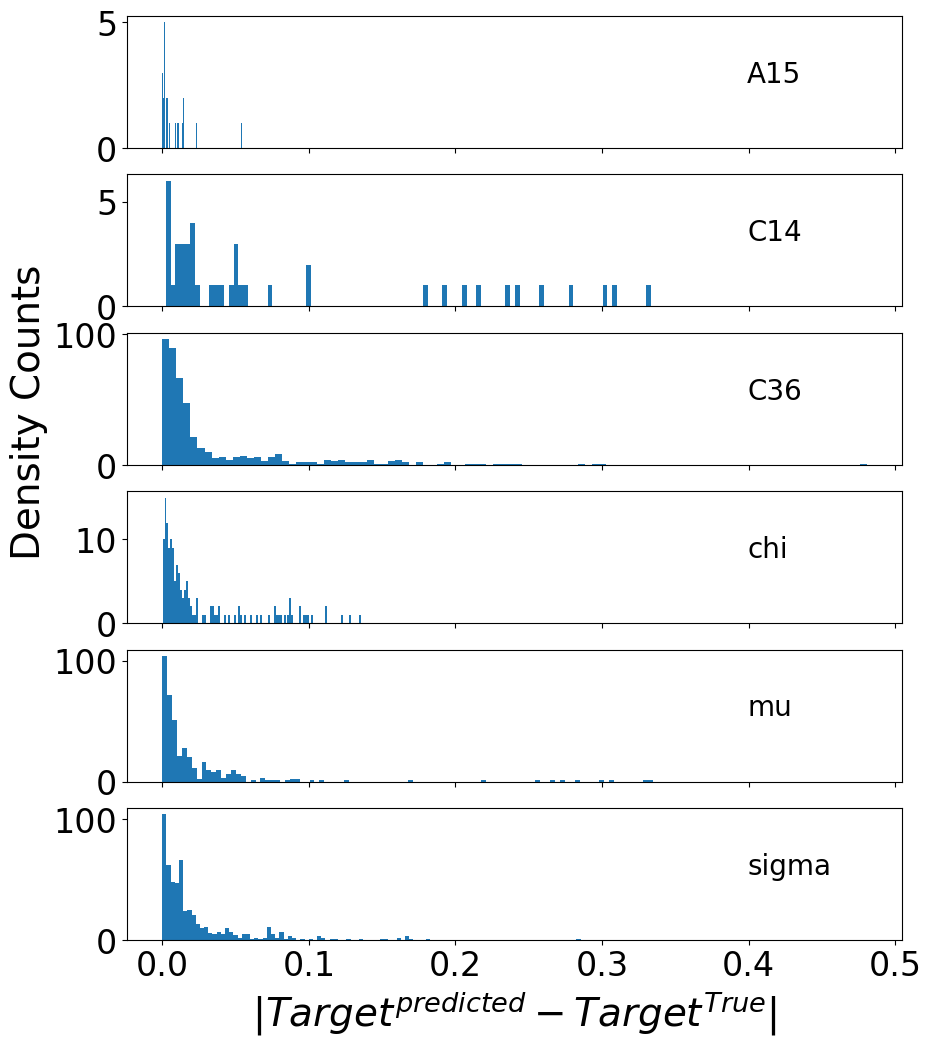

In [55]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [56]:
bigerrors = ERRORS[(ERRORS > 0.15) & ERRORS.index.str.contains('C36')]

In [57]:
import json

In [58]:
with open('evcurves.json', 'r') as f:
    EVCURVES = pd.Series(json.load(f))

In [59]:
import re

In [60]:
EVCURVES.index

Index(['Cr_pv-Co_pv-W_sv/Co_pv_sigma.DDDDD_', 'Cr_pv-Co_pv-W_sv/Co_pv_C15.FM_',
       'Cr_pv-Co_pv-W_sv/Co_pv_sigma.DUDUD_',
       'Cr_pv-Co_pv-W_sv/Co_pv_sigma.DUUDD_', 'Cr_pv-Co_pv-W_sv/Co_pv_hcp_',
       'Cr_pv-Co_pv-W_sv/Co_pv_sigma.DDUDD_', 'Cr_pv-Co_pv-W_sv/Co_pv_bcc_',
       'Cr_pv-Co_pv-W_sv/Co_pv_C14_', 'Cr_pv-Co_pv-W_sv/Co_pv_mu_',
       'Cr_pv-Co_pv-W_sv/Co_pv_sigma.UUUUD_',
       ...
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_mu-ACABA.FM_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_mu-CBBAC_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_C36-CBCAA_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_sigma-AABCA_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_mu-BACCA_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_sigma-BCABA_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_sigma-BCAAC_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_mu-CBBAB.FM_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_sigma-CCBAB_',
       'Cr_pv-Co_pv-W_sv/Cr_pv-Co_pv-W_sv_sigma-CCCAB.FM_'],
      dtype='object', length=

In [61]:
EVCURVES.index = EVCURVES.index.str.split('/').map(lambda i: re.sub('_$','', i[-1]))

Now I will use this vlolume to try to target the formation energy

DATA['VP'] = simple_model.predict(DATA[real_feature])

intermediate_feature = ['VP']

model_formation_energy = RandomForestRegressor()

X_train_ef, X_test_ef , Y_train_ef, Y_test_ef = train_test_split(DATA[real_feature+intermediate_feature], DATA['EF'])

model_formation_energy.fit(X_train_ef, Y_train_ef)

mses['model_formation_energy'] = {
    'test': mean_squared_error(Y_test_ef, model_formation_energy.predict(X_test_ef), squared=False),
    'train': mean_squared_error(Y_train_ef, model_formation_energy.predict(X_train_ef), squared=False)
}

In [62]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381}}

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [63]:
useful_feature = []
for key in useful.keys():
    useful_feature+=useful[key]

In [64]:
Selector = SelectKBest(mutual_info_regression, k=15)
Selector.fit(X_train[useful_feature], Y_train)

SelectKBest(k=15,
            score_func=<function mutual_info_regression at 0x7f2ecb960430>)

In [65]:
simple_model = RandomForestRegressor()

In [66]:
np.array(useful_feature)[Selector.get_support()]

array(['all_NSC_an_4', 'all_NSC_an_5', 'all_NSC_bn_5', 'all_NSC_bn_7',
       'CN12_NSC_bn_2', 'CN12_NSC_bn_5', 'CN12_NSC_bn_7',
       'all_NSC_moments_5', 'all_NSC_moments_6', 'all_NSC_moments_7',
       'all_NSC_moments_8', 'all_NSC_moments_9', 'all_NSC_moments_10',
       'all_NSC_moments_11', 'all_NSC_moments_12'], dtype='<U22')

In [67]:
simple_model.fit(X_train[np.array(useful_feature)[Selector.get_support()]], Y_train)

RandomForestRegressor()

In [68]:
Y_predict = simple_model.predict(X_train[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [69]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381},
 'simplekbest': {'train': 0.05518042381470033, 'test': 0.07880133317620973}}

### on a pipeline

In [70]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest(k=15)),
        ('regression', RandomForestRegressor())
    ]
)

In [71]:
RF_SelectKbest.fit(X_train, Y_train)

Pipeline(steps=[('feature_selection', SelectKBest(k=15)),
                ('regression', RandomForestRegressor())])

In [72]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [73]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

array(['atom_C_', 'atom_C_W_sv', 'avg_dev NdUnfilled', 'range NUnfilled',
       'avg_dev NUnfilled', 'range GSvolume_pa', 'avg_dev GSvolume_pa',
       'range GSmagmom', 'avg_dev GSmagmom', 'range SpaceGroupNumber',
       'avg_dev SpaceGroupNumber', 'CN12_A', 'CN12_B', 'CN16_A', 'CN16_B'],
      dtype='<U27')

In [74]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381},
 'simplekbest': {'train': 0.05518042381470033, 'test': 0.07880133317620973},
 'RF_SK_Pipe': {'train': 0.10147598576071477, 'test': 0.11121533316112925}}

### with cross validation

In [75]:
Params= {'feature_selection__k':np.arange(15,25), 'regression__max_depth':np.arange(20,30)} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [76]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=5,n_jobs=3)

In [77]:
Validator.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(estimator=Pipeline(steps=[('feature_selection', SelectKBest(k=15)),
                                       ('regression',
                                        RandomForestRegressor())]),
             n_jobs=3,
             param_grid={'feature_selection__k': array([15, 16, 17, 18, 19, 20, 21, 22, 23, 24]),
                         'regression__max_depth': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29])},
             scoring='neg_root_mean_squared_error', verbose=5)

In [78]:
Validator.best_estimator_

Pipeline(steps=[('feature_selection', SelectKBest(k=23)),
                ('regression', RandomForestRegressor(max_depth=22))])

In [79]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [80]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [81]:
y = Validator.cv_results_['mean_test_score']

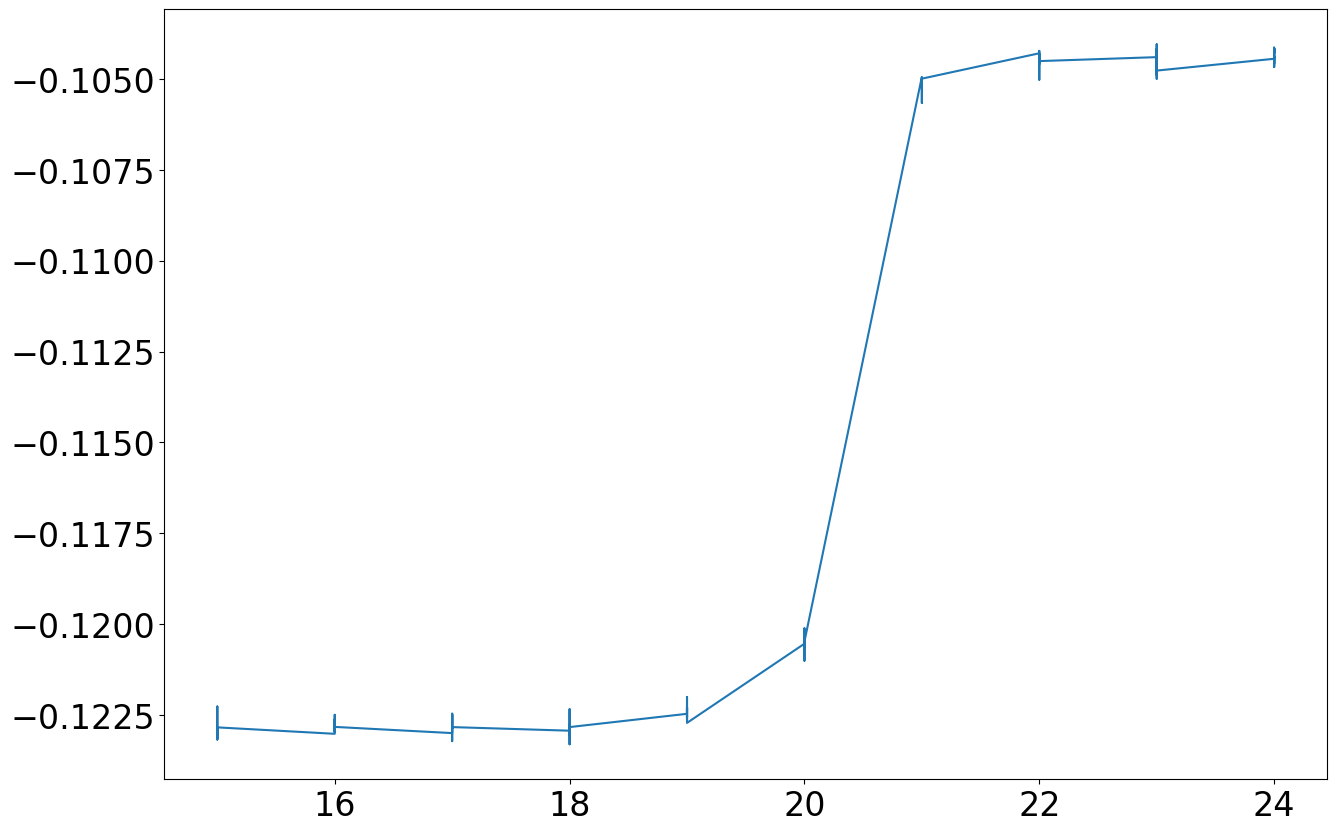

In [82]:
plt.plot(x,y)

In [83]:
X_train.columns[Validator.best_estimator_[0].get_support()]

Index(['CN16_NSC_Ainf_0', 'CN13_NSC_Binf_0', 'CN16_NSC_Binf_0', 'W_sv',
       'atom_A_W_sv', 'atom_B_', 'atom_B_Co_pv', 'atom_B_W_sv', 'atom_C_',
       'atom_C_W_sv', 'avg_dev NdUnfilled', 'range NUnfilled',
       'avg_dev NUnfilled', 'range GSvolume_pa', 'avg_dev GSvolume_pa',
       'range GSmagmom', 'avg_dev GSmagmom', 'range SpaceGroupNumber',
       'avg_dev SpaceGroupNumber', 'CN12_A', 'CN12_B', 'CN16_A', 'CN16_B'],
      dtype='object')

## just in a loop

In [84]:
RF_SelectKbest

Pipeline(steps=[('feature_selection', SelectKBest(k=15)),
                ('regression', RandomForestRegressor())])

In [85]:
for k in range(20,30):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances[:3], model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

20 ['W_sv' 'atom_A_W_sv' 'atom_B_'] [6.59809417e-01 7.85119158e-05 1.78770581e-04] [-0.12079488]
21 ['CN16_NSC_Binf_0' 'W_sv' 'atom_A_W_sv'] [7.29763445e-01 1.08168696e-01 1.08314481e-04] [-0.1051371]
22 ['CN13_NSC_Binf_0' 'CN16_NSC_Binf_0' 'W_sv'] [0.00679112 0.72396639 0.11002366] [-0.10430075]
23 ['CN16_NSC_Ainf_0' 'CN13_NSC_Binf_0' 'CN16_NSC_Binf_0'] [0.05615212 0.00471183 0.70342699] [-0.1046085]
24 ['CN13_NSC_Ainf_0' 'CN16_NSC_Ainf_0' 'CN13_NSC_Binf_0'] [0.00341873 0.05459908 0.00302887] [-0.10446541]
25 ['CN16_NSC_SIGMA_14' 'CN13_NSC_Ainf_0' 'CN16_NSC_Ainf_0'] [0.03205673 0.0025717  0.04636979] [-0.09539765]
26 ['CN16_NSC_SIGMA_13' 'CN16_NSC_SIGMA_14' 'CN13_NSC_Ainf_0'] [0.03750446 0.02473585 0.00282853] [-0.09444843]
27 ['CN16_NSC_SIGMA_12' 'CN16_NSC_SIGMA_13' 'CN16_NSC_SIGMA_14'] [0.02747399 0.03571015 0.01864521] [-0.09425222]
28 ['CN16_NSC_SIGMA_11' 'CN16_NSC_SIGMA_12' 'CN16_NSC_SIGMA_13'] [0.04194341 0.0211372  0.01504078] [-0.09361522]
29 ['CN16_NSC_SIGMA_10' 'CN16_NSC_SIG

In [86]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [87]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381},
 'simplekbest': {'train': 0.05518042381470033, 'test': 0.07880133317620973},
 'RF_SK_Pipe': {'train': 0.10147598576071477, 'test': 0.11121533316112925},
 'RF_SK_pipe': {'test': 0.08275783362536604, 'train': 0.07150041571569923}}

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [88]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [89]:
SeqSelector.fit(X_train, Y_train)

SequentialFeatureSelector(estimator=RandomForestRegressor(),
                          n_features_to_select=10, n_jobs=3,
                          scoring='neg_root_mean_squared_error')

In [90]:
SeqSelector.estimator

RandomForestRegressor()

In [91]:
X_train.columns[SeqSelector.get_support()]

Index(['all_NSC_moments_4', 'CN13_NSC_moments_0', 'CN16_NSC_moments_1',
       'all_NSC_bn_2', 'all_NSC_bn_5', 'CN12_NSC_bn_8', 'CN12_NSC_bn_12',
       'CN13_NSC_bn_12', 'W_sv', 'CN15_B'],
      dtype='object')

In [92]:
features = X_train.columns[SeqSelector.get_support()]

In [93]:
features

Index(['all_NSC_moments_4', 'CN13_NSC_moments_0', 'CN16_NSC_moments_1',
       'all_NSC_bn_2', 'all_NSC_bn_5', 'CN12_NSC_bn_8', 'CN12_NSC_bn_12',
       'CN13_NSC_bn_12', 'W_sv', 'CN15_B'],
      dtype='object')

In [94]:
allfeatures = features.append( pd.Index(['MagConfig']))

In [95]:
allfeatures

Index(['all_NSC_moments_4', 'CN13_NSC_moments_0', 'CN16_NSC_moments_1',
       'all_NSC_bn_2', 'all_NSC_bn_5', 'CN12_NSC_bn_8', 'CN12_NSC_bn_12',
       'CN13_NSC_bn_12', 'W_sv', 'CN15_B', 'MagConfig'],
      dtype='object')

In [96]:
model = RandomForestRegressor(max_depth=20)

In [97]:
model.fit(X_train[features], Y_train)

RandomForestRegressor(max_depth=20)

In [98]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[features]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[features]),squared=False)
}

In [99]:
mses

{'random forest regressor': {'train': 0.05210383351091327,
  'test': 0.07133168739265114},
 'random forest regressor noscale': {'train': 0.052376107259312486,
  'test': 0.0720943885493381},
 'simplekbest': {'train': 0.05518042381470033, 'test': 0.07880133317620973},
 'RF_SK_Pipe': {'train': 0.10147598576071477, 'test': 0.11121533316112925},
 'RF_SK_pipe': {'test': 0.08275783362536604, 'train': 0.07150041571569923},
 'RF_After_SeqSelection': {'test': 0.07191900336297075,
  'train': 0.0540059286291306}}

In [100]:
model.feature_importances_

array([0.09324504, 0.00621031, 0.09975387, 0.15133545, 0.59053001,
       0.00442085, 0.        , 0.        , 0.05450447, 0.        ])

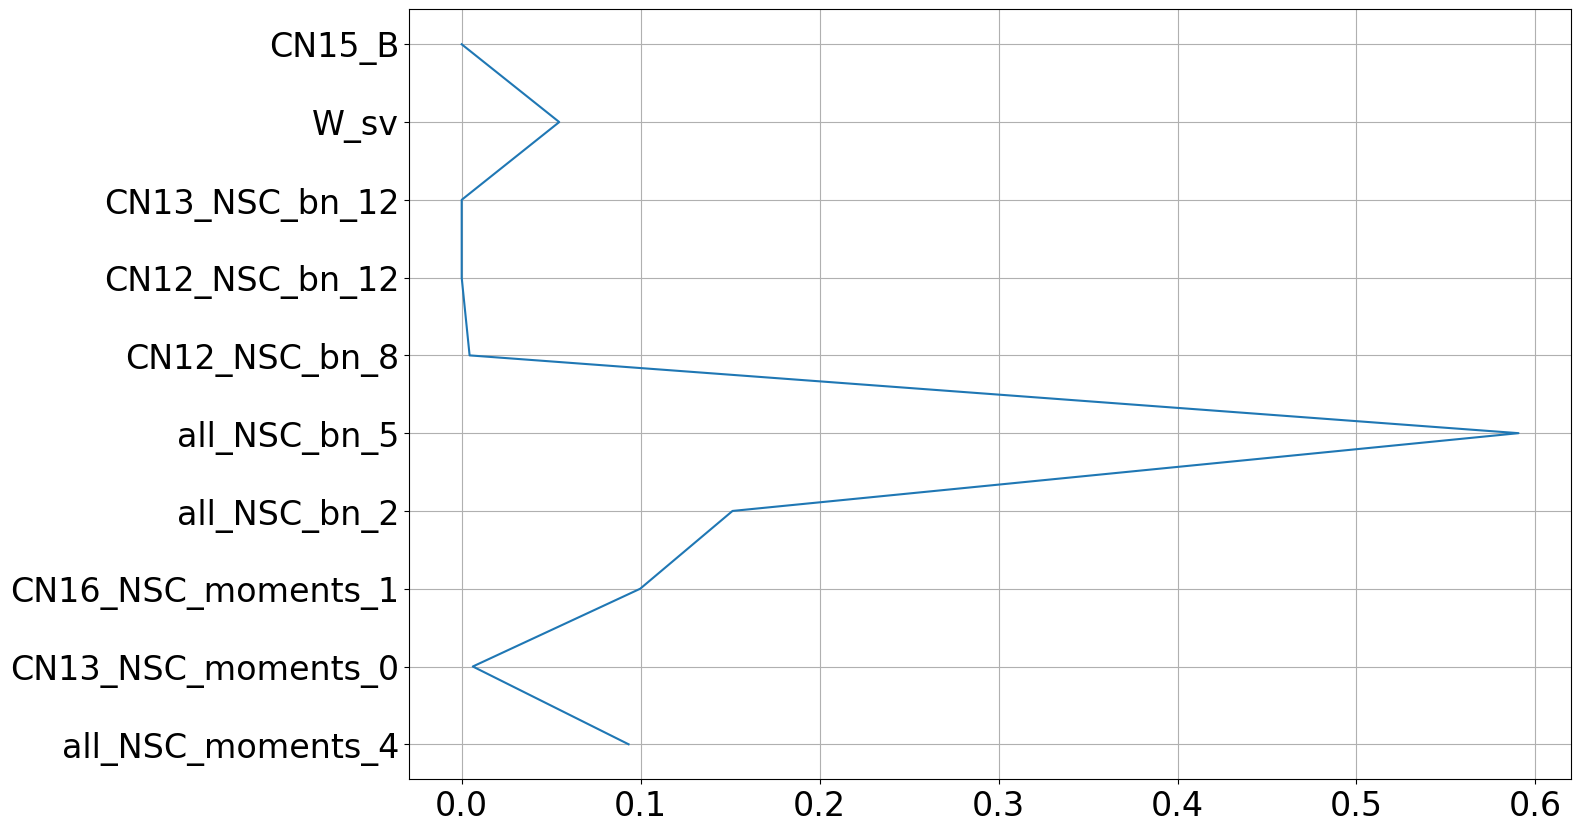

In [101]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, features,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [102]:
import joblib

In [162]:
if os.path.exists('SelectorRFECV_2'):
#    with open('SelectorRFECV','r') as f:
    Selector = joblib.load('SelectorRFECV_2')

else:
    Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                     scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)
    Selector.fit(X_train, Y_train)

    joblib.dump(Selector, 'SelectorRFECV_2')

KeyboardInterrupt: 

In [161]:
X_train.columns[Selector.support_]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 428 but corresponding boolean dimension is 315

In [112]:
Selector.grid_scores_.shape

(306, 5)

In [114]:
Selector.get_feature_names_out()

array(['all_NSC_U_bond_atom_0', 'all_NSC_moments_2', 'all_NSC_moments_5',
       'CN12_NSC_moments_3', 'all_NSC_an_4', 'all_NSC_an_6',
       'CN12_NSC_an_2', 'CN12_NSC_an_3', 'all_NSC_bn_2', 'all_NSC_bn_4',
       'CN16_NSC_bn_4', 'CN16_NSC_bn_5', 'all_NSC_SIGMA_6',
       'all_NSC_SIGMA_8', 'all_NSC_SIGMA_9', 'all_NSC_SIGMA_11',
       'all_NSC_SIGMA_13', 'CN12_NSC_SIGMA_5', 'CN12_NSC_SIGMA_6',
       'CN12_NSC_SIGMA_9', 'CN16_NSC_SIGMA_2', 'all_NSC_Binf_0', 'Co_pv',
       'W_sv', 'avg_dev GSvolume_pa'], dtype=object)

In [152]:
Selector.estimator_.feature_importances_

AttributeError: 'SelectKBest' object has no attribute 'estimator_'

AttributeError: 'SelectKBest' object has no attribute 'estimator_'

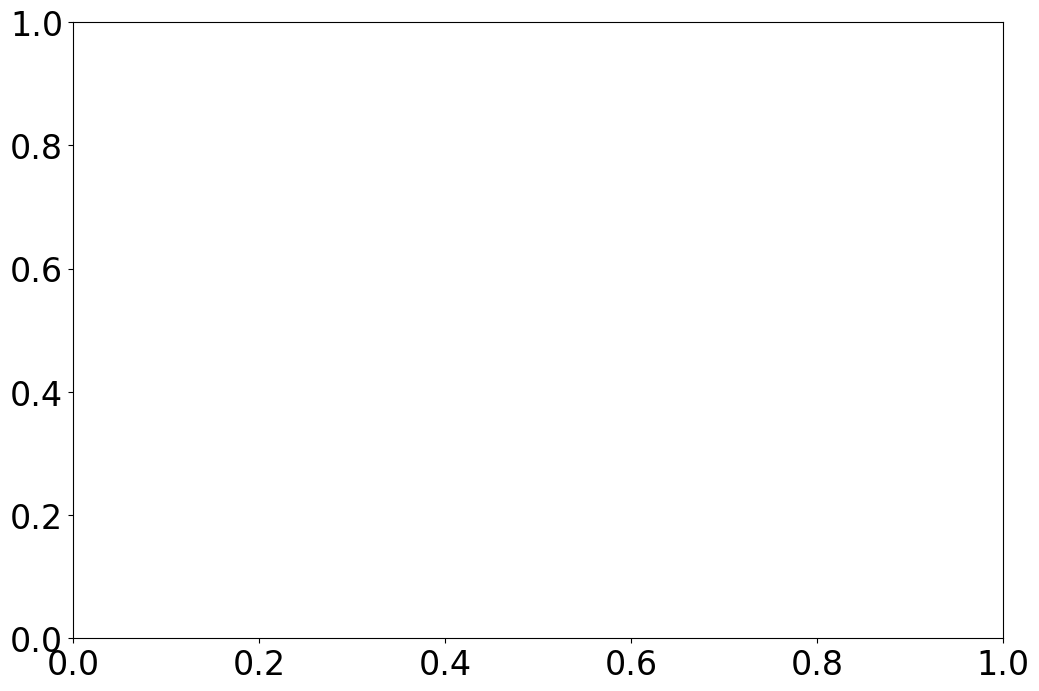

In [151]:
fig, ax = plt.subplots(figsize=(12,8))
ax.bar(Selector.estimator_.feature_importances_, Selector.get_feature_names_out())


In [142]:
rankings = np.unique(Selector.ranking_)

In [ ]:
for rank in rankings:
    print(rank, Selector.feature_names_in_[Selector.ranking_ == rank])

In [151]:
Selector.cv_results_['mean_test_score'][1]

-0.08465598264467852

In [154]:
Selector.cv_results_.keys()

dict_keys(['mean_test_score', 'std_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score'])

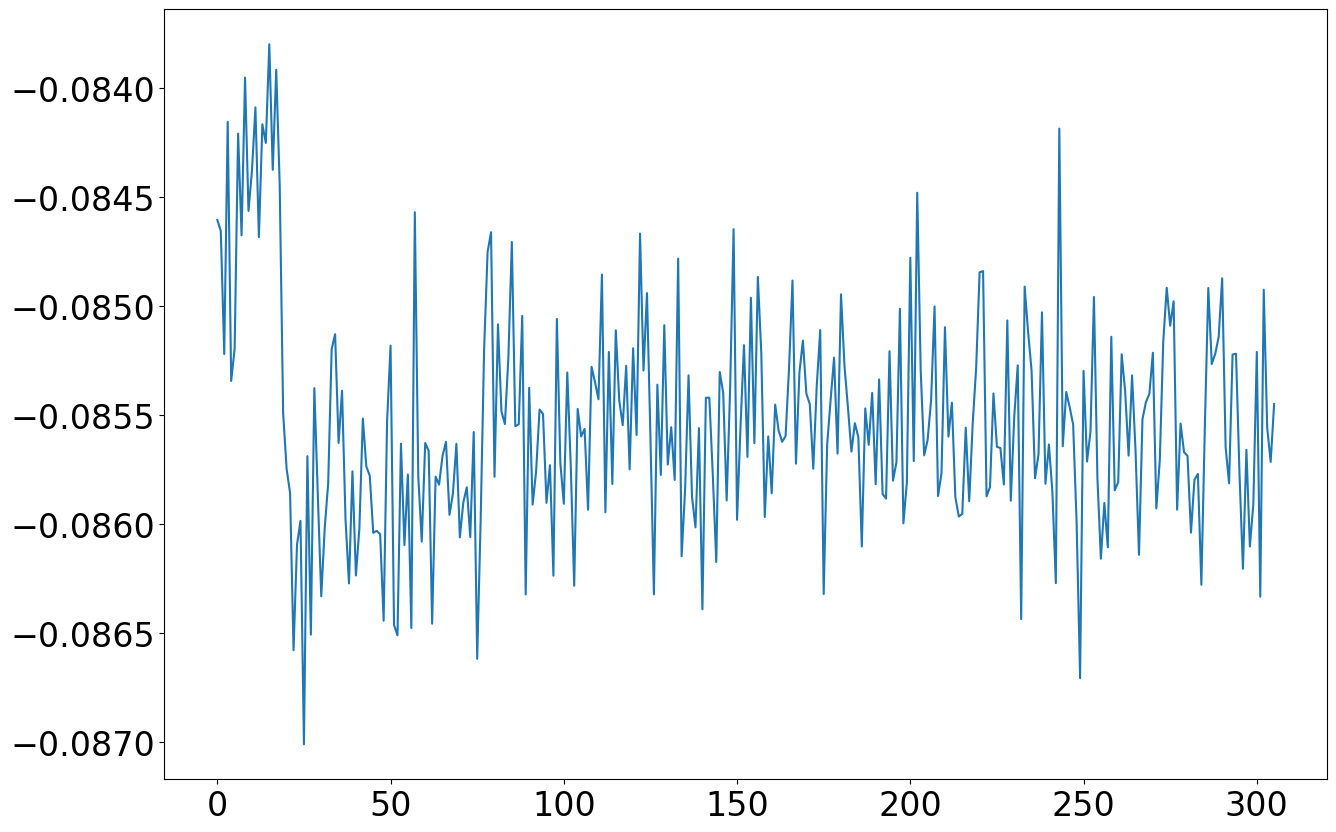

In [153]:
plt.plot(Selector.cv_results_[''])

# My Old Feature Concatenation 

In [191]:
FC = {}

In [192]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

In [193]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

In [194]:
Bestfeats={}
Bestscores={}

In [ ]:
Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_W_CNAV'+CASE
)






  0%|                                                                                             | 0/1 [00:00<?, ?it/s]




procesing '[]' with 'MagConfig' ... ::   0%|                                                      | 0/1 [00:00<?, ?it/s]

Refitting ..







procesing '[]' with 'MagConfig' ... :: 100%|##############################################| 1/1 [00:00<00:00,  1.45it/s]





  0%|                                                                                           | 0/427 [00:00<?, ?it/s]




procesing '['MagConfig']' with 'CN16_NSC_an_4' ... ::   0%|                                     | 0/427 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18608639966799811
Refitting ..







procesing '['MagConfig']' with 'CN16_NSC_an_4' ... ::   0%|                             | 1/427 [00:01<07:54,  1.11s/it]




procesing '['MagConfig']' with 'CN12_NSC_bn_13' ... ::   0%|                            | 1/427 [00:01<07:54,  1.11s/it]




procesing '['MagConfig']' with 'CN12_NSC_bn_13' ... ::   0%|1                           | 2/427 [00:01<06:03,  1.17it/s]




procesing '['MagConfig']' with 'CN12_NSC_an_8' ... ::   0%|1                            | 2/427 [00:01<06:03,  1.17it/s]




procesing '['MagConfig']' with 'CN12_NSC_an_8' ... ::   1%|2                            | 3/427 [00:02<05:27,  1.29it/s]




procesing '['MagConfig']' with 'CN13_NSC_moments_12' ... ::   1%|1                      | 3/427 [00:02<05:27,  1.29it/s]




procesing '['MagConfig']' with 'CN13_NSC_moments_12' ... ::   1%|2                      | 4/427 [00:03<05:25,  1.30it/s]




procesing '['MagConfig']' with 'CN13_NSC_an_10' ... ::   1%|2                           | 4/427 [00:03<05:25,  1.30it/s]

...

fitting has finished,  test_score  =  0.09713881941372342


procesing '['MagConfig', 'CN12_NSC_bn_4', 'all_NSC_moments_8']' with 'CN16_NSC_an_4' ... ::   0%| | 0/320 [00:00<?, ?it/

Refitting ..


procesing '['MagConfig', 'CN12_NSC_bn_4', 'all_NSC_moments_8']' with 'CN15_NSC_SIGMA_5' ... :: 100%|#| 320/320 [09:06<00


fitting has finished,  test_score  =  0.09256108719999694


In [103]:
Bestfeats = {'RandomForest': ['MagConfig',
  'CN12_NSC_bn_4',
  'all_NSC_moments_8',
  'CN16_NSC_an_6',
  'all_NSC_SIGMA_12',
  'CN13_NSC_moments_6',
  'CN13_NSC_moments_5',
  'CN12_NSC_an_0',
  'atom_A_Co_pv',
  'CN14_NSC_SIGMA_5']}

In [104]:
Bestscores= {'RandomForest': [0.18608860088407142,
  0.11118042016926183,
  0.09331017912261931,
  0.08730564519088256,
  0.08564620801250544,
  0.08388554485541029,
  0.08468695039559106,
  0.08554602671207744,
  0.08445457566333901,
  0.08342058096342629]}



In [172]:
first_report = pd.read_pickle('reports/RandomForest_W_CNAVINITIALreport_1.csv')

In [173]:
first_report

,best_estimator,best_score,error,test_score,train_score
CN12_NSC_bn_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.013991,0.074968,0.111180,0.062689
all_NSC_bn_2,"(DecisionTreeRegressor(max_features='auto', ra...",0.013088,0.069630,0.111455,0.054306
all_NSC_moments_10,"(DecisionTreeRegressor(max_features='auto', ra...",0.014253,0.070556,0.112147,0.055433
CN16_NSC_bn_7,"(DecisionTreeRegressor(max_features='auto', ra...",0.014455,0.090558,0.112411,0.084194
all_NSC_moments_8,"(DecisionTreeRegressor(max_features='auto', ra...",0.012406,0.069504,0.112496,0.053561
...,...,...,...,...,...
CN12_NSC_SIGMA_0,"(DecisionTreeRegressor(max_features='auto', ra...",0.035293,0.187148,0.186565,0.187294
atom_A_Co_pv,"(DecisionTreeRegressor(max_features='auto', ra...",0.034853,0.186243,0.186565,0.186163
CN13_NSC_SIGMA_0,"(DecisionTreeRegressor(max_features='auto', ra...",0.035263,0.187166,0.186637,0.187298
atom_A_Cr_pv,"(DecisionTreeRegressor(max_features='auto', ra...",0.034840,0.186213,0.186662,0.186101


In [174]:
FC['RandomForest'].report

,best_estimator,best_score,error,test_score,train_score
CN14_NSC_SIGMA_5,"(DecisionTreeRegressor(max_features='auto', ra...",0.007651,0.057219,0.083421,0.048477
CN14_NSC_SIGMA_8,"(DecisionTreeRegressor(max_features='auto', ra...",0.007650,0.057056,0.083884,0.048035
CN15_NSC_moments_3,"(DecisionTreeRegressor(max_features='auto', ra...",0.007616,0.057388,0.084022,0.048466
CN15_NSC_SIGMA_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.007703,0.057388,0.084436,0.048286
CN15_NSC_moments_1,"(DecisionTreeRegressor(max_features='auto', ra...",0.007596,0.057410,0.084556,0.048266
...,...,...,...,...,...
CN12_NSC_SIGMA_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.007239,0.058595,0.089691,0.047720
CN12_NSC_SIGMA_3,"(DecisionTreeRegressor(max_features='auto', ra...",0.007691,0.058967,0.089836,0.048222
all_NSC_SIGMA_14,"(DecisionTreeRegressor(max_features='auto', ra...",0.007575,0.058900,0.090000,0.048043
all_NSC_SIGMA_7,"(DecisionTreeRegressor(max_features='auto', ra...",0.007353,0.058836,0.090292,0.047806


In [178]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [179]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [180]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')